## 定义模型

In [17]:
from langchain.chat_models import init_chat_model
import os
from dotenv import load_dotenv
load_dotenv()

provider = "modelscope"  # 可选 "modelscope", "dashscope" "openrouter"
model = "Qwen/Qwen3-32B"

if provider == "modelscope":
    model = model if model else os.getenv("MODELSCOPE_MODEL")
    base_url = os.getenv("MODELSCOPE_BASE_URL")
    api_key = os.getenv("MODELSCOPE_API_KEY")
elif provider == "dashscope":
    model = model if model else os.getenv("DASHSCOPE_MODEL")
    base_url = os.getenv("DASHSCOPE_BASE_URL")
    api_key = os.getenv("DASHSCOPE_API_KEY")
elif provider == "openrouter":
    model = model if model else os.getenv("OPENROUTER_MODEL")
    base_url = os.getenv("OPENROUTER_BASE_URL")
    api_key = os.getenv("OPENROUTER_API_KEY")
print(f"Using model [{model}] from provider [{provider}]")

llm = init_chat_model(
    model=model,
    model_provider="openai",
    base_url=base_url,
    api_key=api_key,
    extra_body={"enable_thinking": False} # 可以设置思考模式
)

Using model [Qwen/Qwen3-32B] from provider [modelscope]


## 定义节点

In [18]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display


# Graph state
class State(TypedDict):
    topic: str
    joke: str
    improved_joke: str
    final_joke: str

# Nodes
def generate_joke(state: State):
    """First LLM call to generate initial joke"""

    msg = llm.invoke(f"写一个关于{state['topic']}的简短冷笑话")
    return {"joke": msg.content}


def check_punchline(state: State):
    """Gate function to check if the joke has a punchline"""

    # Simple check - does the joke contain "?" or "!"
    if "?" in state["joke"] or "!" in state["joke"]:
        return "Pass"
    return "Fail"


def improve_joke(state: State):
    """Second LLM call to improve the joke"""

    msg = llm.invoke(f"增加笑话的笑点，简短回答。笑话内容：{state['joke']}，只输出修改后的笑话")
    return {"improved_joke": msg.content}


def polish_joke(state: State):
    """Third LLM call for final polish"""
    msg = llm.invoke(f"给笑话添加转折，简短回答。笑话内容: {state['improved_joke']}，只输出修改后的笑话")
    return {"final_joke": msg.content}

## 构建 Workflow

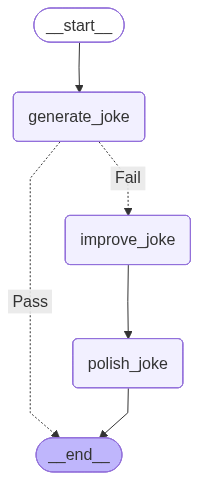

In [19]:
# Build workflow
workflow = StateGraph(State)

# Add nodes
workflow.add_node("generate_joke", generate_joke)
workflow.add_node("improve_joke", improve_joke)
workflow.add_node("polish_joke", polish_joke)

# Add edges to connect nodes
workflow.add_edge(START, "generate_joke")
workflow.add_conditional_edges(
    "generate_joke", check_punchline, {"Fail": "improve_joke", "Pass": END}
)
workflow.add_edge("improve_joke", "polish_joke")
workflow.add_edge("polish_joke", END)

# Compile
chain = workflow.compile()

# Show workflow
display(Image(chain.get_graph().draw_mermaid_png()))

## 运行

In [20]:
# Invoke
state = chain.invoke({"topic": "狗子"})
print("Initial joke:")
print(state["joke"])
print("\n--- --- ---\n")
if "improved_joke" in state:
    print("Improved joke:")
    print(state["improved_joke"])
    print("\n--- --- ---\n")

    print("Final joke:")
    print(state["final_joke"])
else:
    print("Final joke:")
    print(state["joke"])

Initial joke:
狗子去理发店剪了个“忠诚发型”，  
结果一回家，被主人误会成“离家出走”了。

--- --- ---

Improved joke:
狗子去理发店剪了个“忠诚发型”，  
结果一回家，主人吓得报警——以为它假发套的是“隔壁失踪的二哈”。

--- --- ---

Final joke:
狗子去理发店剪了个“忠诚发型”，  
结果一回家，主人吓得报警——以为它假发套的是“隔壁失踪的二哈”。  
警察赶来一看，狗子默默摘下假发：是我。
